In [1]:
 
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# =========================
# CONFIGURACIÓN
# =========================
FILE_PATH = "../../../data/processed/DCABPs/topics_probs.xlsx"
 
ID_COL    = "id"
EVENT_COL = "PD_event"          # 1=PD, 0=censura/no PD observado
TIME_COL  = "Obs_time"  # días hasta PD o censura (OJO: tiene espacio final en tu fichero)
 
# Definición de hipertópico desfavorable (ajústalo si queréis probar 3+5 en vez de 3+4+5)
UNF_TOPICS = [3, 4, 5]  # pUF = p3+p4+p5
 
# Longitud del "mes" para mapear mes->días (en tu Excel es mensual, así que 30 suele ser razonable)
DAYS_PER_MONTH = 30.0
 
# Lookback (AUC rolling) y horizontes de predicción
LOOKBACK_MONTHS_LIST = [3, 4]   # AUC últimos 3 o 4 meses
HORIZON_MONTHS_LIST  = [3, 4]   # predecir PD en próximos 3 o 4 meses
 
# Umbrales candidatos: se generan por cuantiles del predictor (robusto)
N_QUANTILES = 25
 
# Guardar figuras/tablas
SAVE_PREFIX = "alarm_auc_rolling"
 


In [2]:
 
# =========================
# 1) CARGA Y DETECCIÓN DE COLUMNAS DE PROBABILIDADES
# =========================
df = pd.read_excel('../../../data/processed/clinical/Subjects_data.xlsx')
probs_df = pd.read_excel(FILE_PATH)
df=df.merge(probs_df, left_on='S_RECORD_id', right_on='id')

# Detectar columnas tipo mesX_topicY
prob_cols = [c for c in df.columns if re.match(r"mes\d+_topic[0-5]$", str(c))]
if len(prob_cols) == 0:
    raise ValueError("No encuentro columnas tipo 'mesX_topicY'. Revisa nombres de columnas.")
 
# Meses disponibles
months = sorted(set(int(re.findall(r"mes(\d+)_", c)[0]) for c in prob_cols))
max_month = max(months)
 
print(f"N pacientes: {df.shape[0]}")
print(f"Meses detectados: 1..{max_month} (total {len(months)})")
print(f"Columnas de probabilidad detectadas: {len(prob_cols)} (= {len(months)} meses × 6 topics)")
 


N pacientes: 178
Meses detectados: 1..32 (total 32)
Columnas de probabilidad detectadas: 192 (= 32 meses × 6 topics)


In [3]:
# =========================
# 2) CALCULAR pUF POR MES (y dejar NaN si faltan probabilidades del mes)
# =========================
# Regla: pUF(mes) se calcula SOLO si están presentes las 6 probabilidades de ese mes
puf_wide = pd.DataFrame({ID_COL: df[ID_COL].copy()})
 
for m in months:
    cols_all = [f"mes{m}_topic{i}" for i in range(6)]
    cols_unf = [f"mes{m}_topic{i}" for i in UNF_TOPICS]
 
    valid = df[cols_all].notna().all(axis=1)     # requerimos mes completo
    puf   = df[cols_unf].sum(axis=1)
 
    puf_wide[f"m{m}"] = np.where(valid, puf, np.nan)
 
# Pasar a formato largo (una fila por paciente-mes)
long = puf_wide.melt(id_vars=[ID_COL], var_name="m", value_name="pUF")
long["month"] = long["m"].str.replace("m","").astype(int)
long.drop(columns=["m"], inplace=True)
 
# Añadir evento y tiempo
long = long.merge(df[[ID_COL, EVENT_COL, TIME_COL]], on=ID_COL, how="left")
long["event"] = long[EVENT_COL].astype(int)
long["event_time_days"] = long[TIME_COL].astype(float)
 
# Tiempo del "landmark" (fin de mes)
long["t_days"] = long["month"] * DAYS_PER_MONTH
 
# Orden
long = long.sort_values([ID_COL, "month"]).reset_index(drop=True)
 
# QC simple
print("\nCompletitud pUF por mes (n con pUF no-NaN):")
print(long.groupby("month")["pUF"].apply(lambda s: s.notna().sum()).head(12))
print("...")
 



Completitud pUF por mes (n con pUF no-NaN):
month
1     172
2     163
3     154
4     138
5     129
6     122
7     107
8      93
9      84
10     81
11     77
12     69
Name: pUF, dtype: int64
...


In [4]:
# =========================
# 3) AUC / BURDEN ROLLING
# =========================
def add_rolling_features(df_long, W):
    """AUC rolling discreto: suma pUF de los últimos W meses (incluye mes actual)."""
    out = df_long.copy()
    out[f"auc{W}"] = (
        out.groupby(ID_COL)["pUF"]
           .rolling(window=W, min_periods=W)
           .sum()
           .reset_index(level=0, drop=True)
    )
    # (Opcional) media rolling por si quieres compararla con AUC
    out[f"meanpUF{W}"] = (
        out.groupby(ID_COL)["pUF"]
           .rolling(window=W, min_periods=W)
           .mean()
           .reset_index(level=0, drop=True)
    )
    return out
 
# Añadir para todos los W
for W in LOOKBACK_MONTHS_LIST:
    long = add_rolling_features(long, W)


In [5]:
 
# =========================
# 4) CREAR DATASET LANDMARK PARA PREDICCIÓN EN H MESES
# =========================
def make_landmark_dataset(df_long, W, H_months, feature="auc"):
    """
    En cada mes T, con feature(T)=AUC últimos W meses:
      y=1 si PD ocurre en (T, T+H] meses
      y=0 si NO PD ocurre en ese horizonte y hay follow-up suficiente para asegurarlo.
    Manejo censura:
      - Si event=0 (censura) y no llega a cubrir T+H => se excluye (no adjudicable).
      - Se excluyen meses T >= tiempo evento/censura.
    """
    H_days = H_months * DAYS_PER_MONTH
 
    feat_col = f"{feature}{W}" if feature in ["auc", "meanpUF"] else feature
    d = df_long[[ID_COL, "month", "t_days", "pUF", feat_col, "event", "event_time_days"]].copy()
 
    # Requerir feature definido
    d = d.dropna(subset=[feat_col]).copy()
 
    # At risk: T < event/censor time
    d = d[d["t_days"] < d["event_time_days"]].copy()
 
    # Etiqueta
    # Para progresores: positivo si evento cae dentro del horizonte
    y = np.zeros(len(d), dtype=int)
 
    mask_event = d["event"] == 1
    y[mask_event.values] = (d.loc[mask_event, "event_time_days"].values <= (d.loc[mask_event, "t_days"].values + H_days)).astype(int)
 
    # Para censurados: solo adjudicables si censor_time >= T+H
    mask_cens = d["event"] == 0
    ok_cens = d.loc[mask_cens, "event_time_days"].values >= (d.loc[mask_cens, "t_days"].values + H_days)
 
    keep = np.ones(len(d), dtype=bool)
    keep[np.where(mask_cens)[0]] = ok_cens
 
    d = d[keep].copy()
    y = y[keep]
 
    d["y"] = y
    d.rename(columns={feat_col: "x"}, inplace=True)
 
    return d
 


In [6]:
# =========================
# 5) BARRIDO DE UMBRALES + ROC “CASERO”
# =========================
def sweep_thresholds(ds, thresholds):
    rows = []
    y = ds["y"].astype(bool)
    for thr in thresholds:
        pred = ds["x"] >= thr
        TP = int((pred & y).sum())
        FP = int((pred & ~y).sum())
        TN = int((~pred & ~y).sum())
        FN = int((~pred & y).sum())
 
        sens = TP / (TP + FN) if (TP + FN) else np.nan
        spec = TN / (TN + FP) if (TN + FP) else np.nan
        ppv  = TP / (TP + FP) if (TP + FP) else np.nan
        npv  = TN / (TN + FN) if (TN + FN) else np.nan
        J    = sens + spec - 1 if (not np.isnan(sens) and not np.isnan(spec)) else np.nan
 
        rows.append({
            "thr": float(thr),
            "TP": TP, "FP": FP, "TN": TN, "FN": FN,
            "sensitivity": sens, "specificity": spec,
            "PPV": ppv, "NPV": npv,
            "youdenJ": J
        })
    out = pd.DataFrame(rows).sort_values("thr")
    out["FPR"] = 1 - out["specificity"]
    out["TPR"] = out["sensitivity"]
    return out
 
def pick_best_threshold(sweep_df, criterion="youdenJ"):
    best = sweep_df.dropna(subset=[criterion]).sort_values(criterion, ascending=False).head(1)
    if best.empty:
        return None, None
    thr = float(best["thr"].iloc[0])
    return thr, best.iloc[0].to_dict()



=== W=3 meses (AUC) | H=3 meses (horizonte) ===
N decision points: 1087 | Positivos (PD <= H): 125 | Pacientes únicos: 123
Best threshold (Youden): 1.4829
  Sens=0.744 | Spec=0.574 | PPV=0.185 | NPV=0.945 | J=0.318

=== W=3 meses (AUC) | H=4 meses (horizonte) ===
N decision points: 1015 | Positivos (PD <= H): 159 | Pacientes únicos: 115
Best threshold (Youden): 1.6110
  Sens=0.698 | Spec=0.626 | PPV=0.258 | NPV=0.918 | J=0.324

=== W=4 meses (AUC) | H=3 meses (horizonte) ===
N decision points: 964 | Positivos (PD <= H): 114 | Pacientes únicos: 111
Best threshold (Youden): 1.4834
  Sens=0.860 | Spec=0.464 | PPV=0.177 | NPV=0.961 | J=0.323

=== W=4 meses (AUC) | H=4 meses (horizonte) ===
N decision points: 900 | Positivos (PD <= H): 144 | Pacientes únicos: 105
Best threshold (Youden): 1.4789
  Sens=0.854 | Spec=0.479 | PPV=0.238 | NPV=0.945 | J=0.333


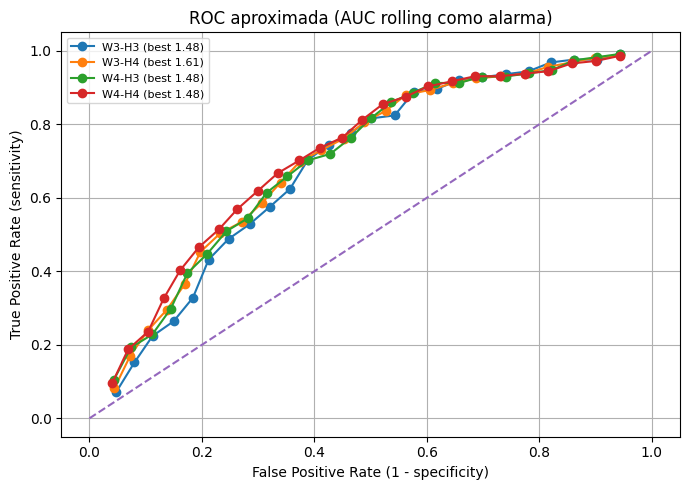

In [7]:
 
# =========================
# 6) EJECUTAR PARA TODAS LAS COMBINACIONES (W,H)
# =========================
all_results = []
plt.figure(figsize=(7,5))
 
for W in LOOKBACK_MONTHS_LIST:
    for H in HORIZON_MONTHS_LIST:
        ds = make_landmark_dataset(long, W=W, H_months=H, feature="auc")
 
        if ds.empty:
            print(f"[W={W}, H={H}] Dataset vacío (probablemente por missingness).")
            continue
 
        # Umbrales por cuantiles
        qs = np.linspace(0.05, 0.95, N_QUANTILES)
        thresholds = np.unique(np.quantile(ds["x"].dropna(), qs))
 
        sw = sweep_thresholds(ds, thresholds)
        best_thr, best_row = pick_best_threshold(sw, criterion="youdenJ")
 
        print(f"\n=== W={W} meses (AUC) | H={H} meses (horizonte) ===")
        print(f"N decision points: {len(ds)} | Positivos (PD <= H): {ds['y'].sum()} | Pacientes únicos: {ds[ID_COL].nunique()}")
        print(f"Best threshold (Youden): {best_thr:.4f}")
        print(f"  Sens={best_row['sensitivity']:.3f} | Spec={best_row['specificity']:.3f} | PPV={best_row['PPV']:.3f} | NPV={best_row['NPV']:.3f} | J={best_row['youdenJ']:.3f}")
 
        # Guardar tabla
        #sw.to_csv(f"{SAVE_PREFIX}_W{W}_H{H}_sweep.csv", index=False)
 
        # Guardar resumen
        all_results.append({
            "W_months": W, "H_months": H,
            "N_points": int(len(ds)),
            "N_pos": int(ds["y"].sum()),
            "N_patients": int(ds[ID_COL].nunique()),
            "best_thr": best_thr,
            **{k: best_row[k] for k in ["TP","FP","TN","FN","sensitivity","specificity","PPV","NPV","youdenJ"]}
        })
 
        # Curva ROC a partir del barrido (aprox)
        plt.plot(sw["FPR"], sw["TPR"], marker="o", linestyle="-", label=f"W{W}-H{H} (best {best_thr:.2f})")
# plot ROC
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate (1 - specificity)")
plt.ylabel("True Positive Rate (sensitivity)")
plt.title("ROC aproximada (AUC rolling como alarma)")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
#plt.savefig(f"{SAVE_PREFIX}_ROC.svg", dpi=300)

plt.show() 
